# Quantized CNN Training for Posture Classification (HGQ2-based QAT)

**Architecture**
- 3 QConv2D layers with QBatchNormalization
- Filter progression: [16, 16, 24]
- GlobalAveragePooling2D for efficiency
- Output: QDense(NUM_CLASSES) (logits output, no softmax)

**Quantization Strategy (HGQ2)**
- Fixed 8-bit quantization (`k0=0`) for both weights and activations
- `kbi` quantizer for weights (SAT_SYM overflow)
- `kif` quantizer for activations (WRAP overflow)
- Effective Bit-Operations (EBOPs) tracking for resource estimation

This notebook follows the HGQ2 best-practice patterns demonstrated in:
- [1] `small_jet_tagger.ipynb`
- [2] `larger_jet_tagger.ipynb`

**Hyperparameters**
- Learning rate: 0.001
- Batch size: 32
- Kernel size: (3, 3)
- L1 regularization: 1e-4
- Early stopping patience: 15
- Max epochs: 50

## Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Keras 3
import keras

# TensorFlow
import tensorflow as tf

# Package imports
from bedposip.data import load_dataset, preprocess_data
from bedposip.model import (
    create_quantized_model,
    get_callbacks,
    train_model,
)
from bedposip.utils import (
    check_layer_trainable_params,
    plot_training_history,
    class_report_metric,
    save_model,
    inspect_quantization_bits, 
    plot_quantization_bits
)

# HGQ2 quantization-aware training
from hgq.config import QuantizerConfigScope, LayerConfigScope
from hgq.utils import trace_minmax
from hgq.regularizers import MonoL1

# Configure matplotlib for PDF export with serif font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Serif",
})

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)

I0000 00:00:1781442605.803972   20726 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Set random seed for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

# Constant number of postures
NUM_CLASSES = 3

# Constant for training quantizers bit-width optimizations
REGULARIZER = 1e-5

# Check GPU
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data

### Loading

In [3]:
# Load datasets using package function
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset(type="raw")


Dataset shapes:
  Train: (119999, 64), labels: (119999,)
  Val:   (60000, 64), labels: (60000,)
  Test:  (120001, 64), labels: (120001,)


### Preprocessing

In [4]:
# Preprocess data using package function
(X_train, y_train, X_val, y_val, X_test, y_test, class_names) = preprocess_data(
    X_train, y_train, X_val, y_val, X_test, y_test,
    num_classes=NUM_CLASSES,
)

Label encoding:
  lateral_L -> 0
  lateral_R -> 1
  supine -> 2

One-hot encoded shape: 3

Reshaped data:
  Train: (119999, 8, 8, 1)
  Val:   (60000, 8, 8, 1)
  Test:  (120001, 8, 8, 1)

Data range: [0.0000, 233.4754]
Data dtype: float32


## Configuration

In [5]:
# Define callbacks using package function
# BetaPID dynamically adjusts beta to steer the model toward a target EBOPs budget.
callbacks = get_callbacks(
    model_name='qat',
    patience=30,
    track_ebops=True,
    target_ebops=800_000,
    init_beta=1e-7,
)

Callbacks configured:
  - EarlyStopping
  - ReduceLROnPlateau
  - FreeEBOPs
  - BetaPID


## Quantized Model

HGQ2 Quantization Configuration

- **`kbi` quantizer** for weights: Fixed 8-bit (4 integer + 4 fractional) with symmetric saturation overflow
- **`kif` quantizer** for activations (datalane): Fixed 8-bit (4 integer + 4 fractional) with wrap-around overflow
- **No softmax in the model**: The output layer produces raw logits

> "QSoftmax is bit-accurate, but it can give exactly zero now: xentropy will diverge and thus USE WITH CAUTION. For classification, it is recommended to NOT to use softmax in the model, but to use it in the loss function"

This approach follows the best practices demonstrated in [1] `small_jet_tagger.ipynb` and [2] `larger_jet_tagger.ipynb`.

In [6]:
from hgq.constraints import MinMax, Max
from hgq.regularizers import MonoL1

with (
    QuantizerConfigScope(place='all', default_q_type='kbi', overflow_mode='SAT_SYM'),
    QuantizerConfigScope(
        place='weight',
        bc=Max(6),
        ic=Max(4),
        i0=2, b0=6,
        br=MonoL1(REGULARIZER),
        ir=MonoL1(REGULARIZER),
        default_q_type='kbi', overflow_mode='SAT_SYM'
    ),
    QuantizerConfigScope(
        place='bias',
        bc=Max(3),
        ic=Max(3),
        i0=2, b0=4,
        br=MonoL1(REGULARIZER),
        ir=MonoL1(REGULARIZER),
        default_q_type='kbi', overflow_mode='SAT_SYM'
    ),
    QuantizerConfigScope(
        place='datalane',
        fc=Max(3),
        ic=Max(6),
        i0=3, f0=3,
        ir=MonoL1(REGULARIZER),
        fr=MonoL1(REGULARIZER),
        default_q_type='kif', overflow_mode='WRAP'
    ),
    LayerConfigScope(enable_ebops=True),  # beta managed by BetaPID callback
):
    model_qat = create_quantized_model(num_classes=NUM_CLASSES)
    model_qat.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.CategoricalCrossentropy(from_logits=True),
        metrics=['accuracy'],
    )

model_qat.summary()

I0000 00:00:1781442608.198646   20726 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5395 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:10:00.0, compute capability: 8.6


Model: "posture_classifier_qat"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_1 (QConv2D)               │ (None, 8, 8, 16)       │           771 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (QBatchNormalization) │ (None, 4, 4, 16)       │           931 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_1 (Activation)         │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_2 (QConv2D)               │ (None, 4, 4, 16)       │         9,987 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 2, 2, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_2 (QBatchNormalization) │ (None, 2, 2, 16)       │           355 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_2 (Activation)         │ (None, 2, 2, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_3 (QConv2D)               │ (None, 2, 2, 24)       │        14,019 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_3 (QBatchNormalization) │ (None, 2, 2, 24)       │           531 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_3 (Activation)         │ (None, 2, 2, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qdense_1 (QDense)               │ (None, 42)             │        16,587 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_1                      │ (None, 42)             │           549 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qdense_2 (QDense)               │ (None, 64)             │        11,137 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_2                      │ (None, 64)             │           835 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (QDense)                 │ (None, 3)              │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,677 (179.33 KB)

 Trainable params: 40,855 (159.59 KB)

 Non-trainable params: 15,822 (19.74 KB)

In [7]:
check_layer_trainable_params(model_qat)

qconv_1: 144
bn_conv_1: 16
qconv_2: 2304
bn_conv_2: 16
qconv_3: 3456
bn_conv_3: 24
qdense_1: 4032
bn_dense_1: 42
qdense_2: 2688
bn_dense_2: 64
output: 192


### Training

Epoch 1/220


I0000 00:00:1781442616.482412   20787 service.cc:153] XLA service 0x7f900c060260 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781442616.482425   20787 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1781442616.783439   20787 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781442618.094144   20787 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1781442618.183667   20787 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_24517__.145
I0000 00:00:1781442619.387161   20787 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I

 3/59 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.3706 - loss: 2.5545  

I0000 00:00:1781442636.141142   20787 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


52/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4905 - loss: 2.3318

I0000 00:00:1781442637.779443   20789 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_24517__.145
I0000 00:00:1781442638.345686   20789 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1781442638.724514   20789 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1781442639.090186   21426 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_34', 36 bytes spill stores, 36 bytes spill loads

I0000 00:00:1781442639.104001   20789 dot_search_space.cc:240] All configs were filtered out because non

59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.5015 - loss: 2.3139

I0000 00:00:1781442659.400288   20787 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1781442660.120583   20787 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


59/59 ━━━━━━━━━━━━━━━━━━━━ 54s 469ms/step - accuracy: 0.5888 - loss: 2.1702 - val_accuracy: 0.3334 - val_loss: 3.3770 - learning_rate: 0.0010 - ebops: 2005401.0000 - beta: 1.0000e-07
Epoch 2/220
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7643 - loss: 1.8444 - val_accuracy: 0.4837 - val_loss: 2.6846 - learning_rate: 0.0010 - ebops: 1952577.0000 - beta: 1.0000e-07
Epoch 3/220
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8042 - loss: 1.7477 - val_accuracy: 0.5724 - val_loss: 2.0589 - learning_rate: 0.0010 - ebops: 1938783.0000 - beta: 1.0000e-07
Epoch 4/220
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8210 - loss: 1.7035 - val_accuracy: 0.6138 - val_loss: 2.1014 - learning_rate: 0.0010 - ebops: 1940535.0000 - beta: 1.0000e-07
Epoch 5/220
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8338 - loss: 1.6688 - val_accuracy: 0.6908 - val_loss: 1.8410 - learning_rate: 0.0010 - ebops: 1937733.0000 - beta: 1.0000e-07
Epoch 6/220
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/ste

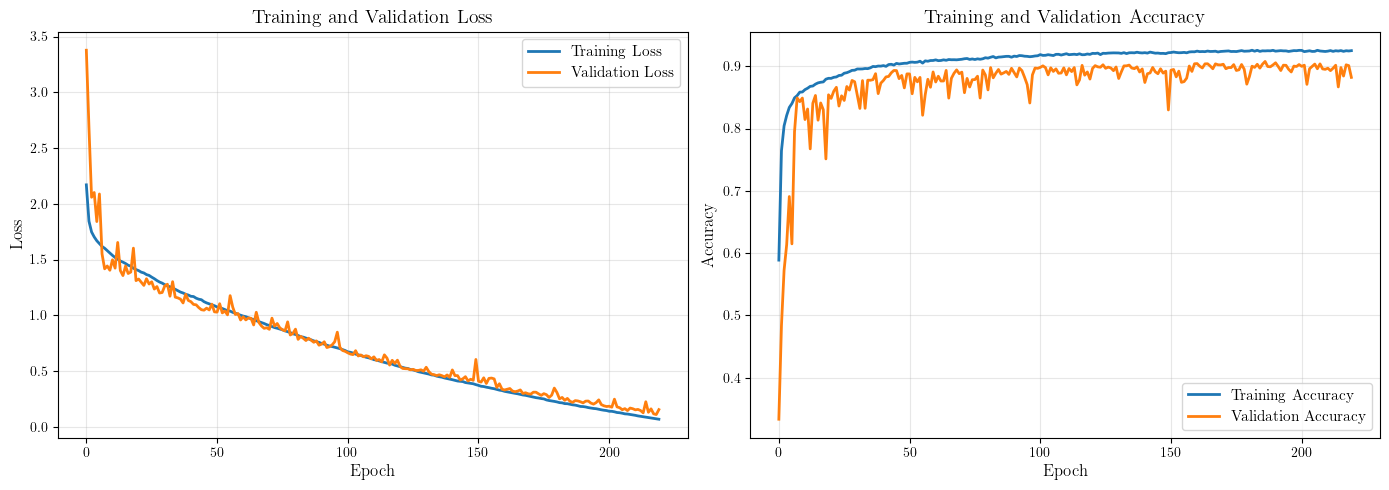

In [8]:
history_qat = train_model(model_qat, X_train,y_train, X_val, y_val, callbacks, batch_size=2048, epochs=220) # Batch according to HGQ article
plot_training_history(history_qat, model_name='posture_classifier_qat', save=True)

## Model Evaluation

In [9]:
class_report_metric(model_qat, X_test, y_test, class_names)

I0000 00:00:1781442736.212792   20789 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.



Accuracy Report for `posture_classifier_qat`:
  Loss: 0.1148
  Accuracy: 89.97%

Classification Report for `posture_classifier_qat`:
              precision    recall  f1-score   support

   lateral_L     0.8878    0.9166    0.9020     40000
   lateral_R     0.9071    0.8856    0.8962     40000
      supine     0.9049    0.8970    0.9009     40001

    accuracy                         0.8997    120001
   macro avg     0.8999    0.8997    0.8997    120001
weighted avg     0.8999    0.8997    0.8997    120001



In [10]:
# Inspect learned quantization bit-widths
# bits_info = inspect_quantization_bits(model_qat, report=True)

# plot_quantization_bits(model_qat, bits_info=bits_info, save=False)


In [11]:
# From larger_jet_tagger

# When using `WRAP` overflow mode for activations (datalane), HGQ2 needs to know the min/max values of each layer's activations to determine the required integer bits. 
trace_minmax(model_qat, X_train, batch_size=2048, reset=True)
ebops = trace_minmax(model_qat, X_val, batch_size=2048, reset=False)

lut_pred = np.exp(0.985 * np.log(ebops))
dsp_pred = (ebops - lut_pred) / 55

print("Resource Estimation Report")
print("="*40)
print(f"\nEBOPs: {ebops} \nLUTs: {lut_pred:.0f} \nDSPs: {dsp_pred:.0f}")

Resource Estimation Report

EBOPs: 605561 
LUTs: 495936 
DSPs: 1993


In [12]:
## Determine accuracy of Keras model, for comparison
keras_score = model_qat.evaluate(X_test, y_test, verbose=0)

print("="*80)    
print("Keras  model evaluation \t Loss: {:.2f} \t Accuracy: {:.2f}%".format(keras_score[0], keras_score[1]*100))
print("="*80)

Keras  model evaluation 	 Loss: 0.93 	 Accuracy: 66.98%


In [13]:
# Inspect learned quantization bit-widths
bits_info = inspect_quantization_bits(model_qat, report=True)

# plot_quantization_bits(model_qat, bits_info=bits_info, save=False)


Quantization Bit-width Report:
pressure_map: InputLayer (no quantizers)

qconv_1 (QConv2D):
  iq: bits=4.78, fbits=4.78, type=kif
  kq: bits=4.13, fbits=5.13, type=kbi
pool_1: MaxPooling2D (no quantizers)

bn_conv_1 (QBatchNormalization):
  iq: bits=4.82, fbits=5.62, type=kif
  kq: bits=6.00, fbits=7.00, type=kbi
  bq: bits=2.94, fbits=3.94, type=kbi
conv_act_1: Activation (no quantizers)

qconv_2 (QConv2D):
  iq: bits=4.87, fbits=4.87, type=kif
  kq: bits=2.46, fbits=3.46, type=kbi
pool_2: MaxPooling2D (no quantizers)

bn_conv_2 (QBatchNormalization):
  iq: bits=6.95, fbits=7.89, type=kif
  kq: bits=5.38, fbits=6.38, type=kbi
  bq: bits=3.00, fbits=4.00, type=kbi
conv_act_2: Activation (no quantizers)

qconv_3 (QConv2D):
  iq: bits=6.17, fbits=6.17, type=kif
  kq: bits=1.84, fbits=2.84, type=kbi

bn_conv_3 (QBatchNormalization):
  iq: bits=6.27, fbits=7.27, type=kif
  kq: bits=4.25, fbits=5.25, type=kbi
  bq: bits=2.79, fbits=3.79, type=kbi
conv_act_3: Activation (no quantizers)
flat

In [14]:
# Overall sparsity
weights = model_qat.get_weights()
sparsity = sum(np.sum(w == 0) for w in weights) / sum(w.size for w in weights) * 100
print(f"Sparsity: {sparsity:.2f}%")

# Per-layer sparsity
for i, w in enumerate(model_qat.get_weights()):
    print(f"Layer {i}: {np.sum(w == 0) / w.size * 100:.2f}% sparsity ({np.sum(w == 0)}/{w.size} zeros)")

# Near-zero tolerance for quantized weights
tol = 1e-1
sparsity = sum(np.sum(np.abs(w) < tol) for w in weights) / sum(w.size for w in weights) * 100
print(f"Sparsity: {sparsity:.2f}%")

Sparsity: 1.14%
Layer 0: 0.00% sparsity (0/144 zeros)
Layer 1: 0.00% sparsity (0/1 zeros)
Layer 2: 0.00% sparsity (0/1 zeros)
Layer 3: 0.00% sparsity (0/64 zeros)
Layer 4: 100.00% sparsity (64/64 zeros)
Layer 5: 0.00% sparsity (0/64 zeros)
Layer 6: 0.00% sparsity (0/1 zeros)
Layer 7: 0.00% sparsity (0/144 zeros)
Layer 8: 0.00% sparsity (0/144 zeros)
Layer 9: 0.00% sparsity (0/144 zeros)
Layer 10: 0.00% sparsity (0/16 zeros)
Layer 11: 0.00% sparsity (0/16 zeros)
Layer 12: 0.00% sparsity (0/16 zeros)
Layer 13: 0.00% sparsity (0/16 zeros)
Layer 14: 0.00% sparsity (0/1 zeros)
Layer 15: 0.00% sparsity (0/1 zeros)
Layer 16: 0.00% sparsity (0/256 zeros)
Layer 17: 20.31% sparsity (52/256 zeros)
Layer 18: 0.00% sparsity (0/256 zeros)
Layer 19: 0.00% sparsity (0/1 zeros)
Layer 20: 0.00% sparsity (0/16 zeros)
Layer 21: 0.00% sparsity (0/16 zeros)
Layer 22: 0.00% sparsity (0/16 zeros)
Layer 23: 0.00% sparsity (0/16 zeros)
Layer 24: 0.00% sparsity (0/16 zeros)
Layer 25: 0.00% sparsity (0/16 zeros)


In [15]:
from numpy import linalg as LA

def weight_prune_dense_layer(k_weights, b_weights, k_sparsity):
    """
    Takes in matrices of kernel and bias weights (for a dense
      layer) and returns the unit-pruned versions of each
    Args:
      k_weights: 2D matrix of the 
      b_weights: 1D matrix of the biases of a dense layer
      k_sparsity: percentage of weights to set to 0
    Returns:
      kernel_weights: sparse matrix with same shape as the original
        kernel weight matrix
      bias_weights: sparse array with same shape as the original
        bias array
    """
    # Copy the kernel weights and get ranked indeces of the abs
    kernel_weights = np.copy(k_weights)
    ind = np.unravel_index(
        np.argsort(
            np.abs(kernel_weights),
            axis=None),
        kernel_weights.shape)
        
    # Number of indexes to set to 0
    cutoff = int(len(ind[0])*k_sparsity)
    # The indexes in the 2D kernel weight matrix to set to 0
    sparse_cutoff_inds = (ind[0][0:cutoff], ind[1][0:cutoff])
    kernel_weights[sparse_cutoff_inds] = 0.
        
    # Copy the bias weights and get ranked indeces of the abs
    bias_weights = np.copy(b_weights)

    if bias_weights.ndim == 0:
        return kernel_weights, bias_weights

    ind = np.unravel_index(
        np.argsort(
            np.abs(bias_weights),
            axis=None),
        bias_weights.shape)
        
    # Number of indexes to set to 0
    cutoff = int(len(ind[0])*k_sparsity)
    # The indexes in the 1D bias weight matrix to set to 0
    sparse_cutoff_inds = (ind[0][0:cutoff])
    bias_weights[sparse_cutoff_inds] = 0.
    
    return kernel_weights, bias_weights
  

def unit_prune_dense_layer(k_weights, b_weights, k_sparsity):
    """
    Takes in matrices of kernel and bias weights (for a dense
      layer) and returns the unit-pruned versions of each
    Args:
      k_weights: 2D matrix of the 
      b_weights: 1D matrix of the biases of a dense layer
      k_sparsity: percentage of weights to set to 0
    Returns:
      kernel_weights: sparse matrix with same shape as the original
        kernel weight matrix
      bias_weights: sparse array with same shape as the original
        bias array
    """

    # Copy the kernel weights and get ranked indeces of the
    # column-wise L2 Norms
    kernel_weights = np.copy(k_weights)
    ind = np.argsort(LA.norm(kernel_weights, axis=0))
        
    # Number of indexes to set to 0
    cutoff = int(len(ind)*k_sparsity)
    # The indexes in the 2D kernel weight matrix to set to 0
    sparse_cutoff_inds = ind[0:cutoff]
    kernel_weights[:,sparse_cutoff_inds] = 0.
        
    # Copy the bias weights and get ranked indeces of the abs
    bias_weights = np.copy(b_weights)
    # The indexes in the 1D bias weight matrix to set to 0
    # Equal to the indexes of the columns that were removed in this case
    #sparse_cutoff_inds
    bias_weights[sparse_cutoff_inds] = 0.
    
    return kernel_weights, bias_weights

In [16]:
def sparsify_model(model, x_test, y_test, k_sparsity, pruning='weight'):
    """
    Takes in a model made of dense layers and prunes the weights
    Args:
      model: Keras model
      k_sparsity: target sparsity of the model
    Returns:
      sparse_model: sparsified copy of the previous model
    """
    # Copying a temporary sparse model from our original
    sparse_model = tf.keras.models.clone_model(model)
    sparse_model.set_weights(model.get_weights())
    
    # Getting a list of the names of each component (w + b) of each layer
    names = [weight.name for layer in sparse_model.layers for weight in layer.weights]
    # Getting the list of the weights for each component (w + b) of each layer
    weights = sparse_model.get_weights()
    
    # Initializing list that will contain the new sparse weights
    newWeightList = []

    # Iterate over all but the final 2 layers (the softmax)
    for i in range(0, len(weights)-2, 2):
        
        if pruning=='weight':
            kernel_weights, bias_weights = weight_prune_dense_layer(weights[i],
                                                                    weights[i+1],
                                                                    k_sparsity)
        elif pruning=='unit':
            kernel_weights, bias_weights = unit_prune_dense_layer(weights[i],
                                                                  weights[i+1],
                                                                  k_sparsity)
        else:
            print('does not match available pruning methods ( weight | unit )')
        
        # Append the new weight list with our sparsified kernel weights
        newWeightList.append(kernel_weights)
        
        # Append the new weight list with our sparsified bias weights
        newWeightList.append(bias_weights)

    # Adding the unchanged weights of the final 2 layers
    for i in range(len(weights)-2, len(weights)):
        unmodified_weight = np.copy(weights[i])
        newWeightList.append(unmodified_weight)

    # Setting the weights of our model to the new ones
    sparse_model.set_weights(newWeightList)
    
    # Re-compiling the Keras model (necessary for using `evaluate()`)
    sparse_model.compile(
        loss=tf.keras.losses.categorical_crossentropy,
        optimizer='adam',
        metrics=['accuracy'])
    
    # Printing the the associated loss & Accuracy for the k% sparsity
    score = sparse_model.evaluate(x_test, y_test, verbose=0)
    print('k% weight sparsity: ', k_sparsity,
          '\tTest loss: {:07.5f}'.format(score[0]),
          '\tTest accuracy: {:05.2f} %%'.format(score[1]*100.))
    
    return sparse_model, score
 

In [17]:
sparse_model, score = sparsify_model(model_qat, X_test, y_test, 0.25, pruning='weight')

ValueError: multiple indices are not supported for 0d arrays

In [ ]:
# Per-layer magnitude pruning at 50% sparsity
# def prune_per_layer(model, sparsity=0.5):
#     weights = model.get_weights()
#     new_weights = []
#     for w in weights:
#         if w.size == 0:
#             new_weights.append(w)
#             continue
#         threshold = np.percentile(np.abs(w), sparsity * 100)
#         mask = np.abs(w) > threshold
#         new_weights.append(w * mask)
#     model.set_weights(new_weights)

# # Apply 50% per-layer pruning
# prune_per_layer(model_qat, sparsity=0.5)

# Verify post-pruning sparsity
weights = model_qat.get_weights()
total_zeros = sum(np.sum(w == 0) for w in weights)
total_params = sum(w.size for w in weights)
print(f"Post-prune sparsity: {total_zeros/total_params*100:.2f}%")

# Per-layer sparsity report
for i, w in enumerate(weights):
    layer_sparsity = np.sum(w == 0) / w.size * 100
    print(f"Layer {i}: {layer_sparsity:.2f}% sparsity ({np.sum(w == 0)}/{w.size} zeros)")

# Recompile after pruning
model_qat.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

# Evaluate before fine-tuning
print("\n" + "="*70)
print("Accuracy BEFORE fine-tuning after pruning:")
print("="*70)
results_before = model_qat.evaluate(X_val, y_val, verbose=1)
print(f"Loss: {results_before[0]:.4f}")
print(f"Accuracy: {results_before[1]*100:.2f}%")

# Fine-tune for 10 epochs
print("Fine-tuning for 10 epochs...")
history = model_qat.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=1
)

# Evaluate after fine-tuning
print("\n" + "="*70)
print("Accuracy AFTER 10 epochs of fine-tuning:")
print("="*70)
results_after = model_qat.evaluate(X_val, y_val, verbose=1)
print(f"Loss: {results_after[0]:.4f}")
print(f"Accuracy: {results_after[1]*100:.2f}%")

# Final sparsity check
weights = model_qat.get_weights()
total_zeros = sum(np.sum(w == 0) for w in weights)
total_params = sum(w.size for w in weights)
print(f"\nFinal post-fine-tune sparsity: {total_zeros/total_params*100:.2f}%")
for i, w in enumerate(weights):
    layer_sparsity = np.sum(w == 0) / w.size * 100
    print(f"Layer {i}: {layer_sparsity:.2f}% sparsity ({np.sum(w == 0)}/{w.size} zeros)")

Post-prune sparsity: 63.46%
Layer 0: 50.00% sparsity (72/144 zeros)
Layer 1: 100.00% sparsity (1/1 zeros)
Layer 2: 100.00% sparsity (1/1 zeros)
Layer 3: 50.00% sparsity (32/64 zeros)
Layer 4: 100.00% sparsity (64/64 zeros)
Layer 5: 100.00% sparsity (64/64 zeros)
Layer 6: 100.00% sparsity (1/1 zeros)
Layer 7: 50.00% sparsity (72/144 zeros)
Layer 8: 50.00% sparsity (72/144 zeros)
Layer 9: 100.00% sparsity (144/144 zeros)
Layer 10: 50.00% sparsity (8/16 zeros)
Layer 11: 50.00% sparsity (8/16 zeros)
Layer 12: 50.00% sparsity (8/16 zeros)
Layer 13: 50.00% sparsity (8/16 zeros)
Layer 14: 100.00% sparsity (1/1 zeros)
Layer 15: 100.00% sparsity (1/1 zeros)
Layer 16: 50.00% sparsity (128/256 zeros)
Layer 17: 100.00% sparsity (256/256 zeros)
Layer 18: 100.00% sparsity (256/256 zeros)
Layer 19: 100.00% sparsity (1/1 zeros)
Layer 20: 50.00% sparsity (8/16 zeros)
Layer 21: 50.00% sparsity (8/16 zeros)
Layer 22: 100.00% sparsity (16/16 zeros)
Layer 23: 50.00% sparsity (8/16 zeros)
Layer 24: 50.00% s

I0000 00:00:1781315798.046104    9300 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_490287__.145
I0000 00:00:1781315798.809420    9300 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1781315799.311181   23333 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_26', 132 bytes spill stores, 132 bytes spill loads



3740/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3714 - loss: 0.9733

I0000 00:00:1781315821.595113    9301 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_490287__.145
I0000 00:00:1781315822.299831    9301 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


3750/3750 ━━━━━━━━━━━━━━━━━━━━ 49s 7ms/step - accuracy: 0.3950 - loss: 0.5433 - val_accuracy: 0.4278 - val_loss: -0.0036
Epoch 2/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.4222 - loss: -0.5026 - val_accuracy: 0.4429 - val_loss: -1.0041
Epoch 3/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.4406 - loss: -1.5055 - val_accuracy: 0.4638 - val_loss: -2.0141
Epoch 4/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.4582 - loss: -2.5135 - val_accuracy: 0.4857 - val_loss: -3.0350
Epoch 5/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.4738 - loss: -3.5312 - val_accuracy: 0.4825 - val_loss: -4.0344
Epoch 6/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.4881 - loss: -4.5515 - val_accuracy: 0.4638 - val_loss: -5.0630
Epoch 7/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.4923 - loss: -5.5602 - val_accuracy: 0.4473 - val_loss: -6.0550
Epoch 8/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.4934 - loss:

## Model Saving

In [ ]:
# Save model
save_model(model_qat, output_dir='output')


Model saved to: output/posture_classifier_qat.keras

Verification:
  Loaded successfully: True
  Model name: posture_classifier_qat
  Total parameters: 56,677
